# Digital Crime Investigation
## Notebook 01 — Data Cleaning & Validation

**Author:** Baskara Kresna Juniarto  
**Project:** Transaction Fraud & Anomaly Analytics  
**Scope:** Data Analyst Portfolio  

---
This notebook covers Phase 1 of the investigation pipeline:
- Load all four source tables
- Assess data quality (nulls, duplicates, type errors, out-of-range values)
- Apply cleaning transformations and document decisions
- Export cleaned data for downstream analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.0f}'.format)

DATA_DIR = Path('/content/')
IMG_DIR  = Path('/content/images/')
print('Data directory:', DATA_DIR)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.0f}'.format)

DATA_DIR = Path('../data')
print('Data directory:', DATA_DIR.resolve())

Data directory: C:\Users\baska\Documents\GitHub\digital-crime-investigation\data


## 1. Load Raw Data

In [2]:
txn      = pd.read_csv(DATA_DIR / 'transactions.csv', parse_dates=['timestamp'])
users    = pd.read_csv(DATA_DIR / 'users.csv', parse_dates=['registration_date'])
devices  = pd.read_csv(DATA_DIR / 'devices.csv', parse_dates=['first_seen', 'last_seen'])
merchants= pd.read_csv(DATA_DIR / 'merchants.csv')

print(f'Transactions : {len(txn):,} rows  x  {txn.shape[1]} cols')
print(f'Users        : {len(users):,} rows  x  {users.shape[1]} cols')
print(f'Devices      : {len(devices):,} rows  x  {devices.shape[1]} cols')
print(f'Merchants    : {len(merchants):,} rows  x  {merchants.shape[1]} cols')

Transactions : 433 rows  x  12 cols
Users        : 200 rows  x  5 cols
Devices      : 160 rows  x  5 cols
Merchants    : 80 rows  x  4 cols


## 2. Schema Inspection

In [3]:
txn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433 entries, 0 to 432
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      433 non-null    object        
 1   user_id             433 non-null    object        
 2   timestamp           433 non-null    datetime64[ns]
 3   amount              433 non-null    float64       
 4   merchant_id         433 non-null    object        
 5   category            433 non-null    object        
 6   location_id         433 non-null    object        
 7   device_id           433 non-null    object        
 8   payment_method      433 non-null    object        
 9   transaction_status  433 non-null    object        
 10  refund_flag         433 non-null    int64         
 11  chargeback_flag     433 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(8)
memory usage: 40.7+ KB


In [4]:
txn.head(10)

,transaction_id,user_id,timestamp,amount,merchant_id,category,location_id,device_id,payment_method,transaction_status,refund_flag,chargeback_flag
0,T000426,U0082,2024-03-24 20:01:45,"100,577",M0027,entertainment,Surabaya,D0150,e-wallet,completed,0,0
1,T000076,U0005,2024-04-24 10:57:01,"469,089",M0029,gaming,Makassar,D0005,debit_card,completed,0,0
2,T000182,U0105,2024-05-22 10:28:20,"42,991",M0041,transfer,Yogyakarta,D0105,credit_card,completed,0,0
3,T000031,U0045,2024-06-07 11:20:29,"290,878",M0046,food_beverage,Bali,D0045,debit_card,failed,0,0
4,T000365,U0078,2024-05-04 02:12:45,"158,330",M0048,e-commerce,Semarang,D0078,credit_card,completed,0,0
5,T000409,U0156,2024-02-07 23:12:01,"160,196",M0047,retail,Semarang,D0156,credit_card,completed,0,0
6,T000254,U0123,2024-03-23 08:11:42,"362,504",M0038,gaming,Jakarta,D0123,e-wallet,pending,0,0
7,T000156,U0199,2024-02-22 16:19:21,"664,329",M0051,travel,Jakarta,D0160,e-wallet,completed,0,0
8,T000169,U0019,2024-06-01 20:06:39,"95,261",M0030,e-commerce,Bali,D0019,debit_card,completed,0,0
9,T000416,U0103,2024-01-24 11:32:20,"13,168,790",M0005,transfer,Jakarta,D0103,bank_transfer,completed,0,0


## 3. Missing Value Analysis

In [5]:
def null_report(df, label):
    null_cnt = df.isnull().sum()
    null_pct = (null_cnt / len(df) * 100).round(2)
    report = pd.DataFrame({'null_count': null_cnt, 'null_pct': null_pct})
    report = report[report.null_count > 0].sort_values('null_count', ascending=False)
    print(f'\n=== {label} — Null Report ===')
    print(report if len(report) else 'No nulls found. ✓')

for df, name in [(txn, 'transactions'), (users, 'users'),
                 (devices, 'devices'), (merchants, 'merchants')]:
    null_report(df, name)


=== transactions — Null Report ===
No nulls found. ✓

=== users — Null Report ===
No nulls found. ✓

=== devices — Null Report ===
No nulls found. ✓

=== merchants — Null Report ===
No nulls found. ✓


## 4. Duplicate Check

In [6]:
print('Duplicate transaction_id:', txn.duplicated(subset='transaction_id').sum())
print('Duplicate user_id       :', users.duplicated(subset='user_id').sum())
print('Duplicate device_id     :', devices.duplicated(subset='device_id').sum())
print('Duplicate merchant_id   :', merchants.duplicated(subset='merchant_id').sum())

Duplicate transaction_id: 0
Duplicate user_id       : 0
Duplicate device_id     : 0
Duplicate merchant_id   : 0


## 5. Categorical Value Audit

In [7]:
EXPECTED = {
    'transaction_status': {'completed', 'pending', 'failed'},
    'payment_method'    : {'credit_card', 'debit_card', 'e-wallet', 'bank_transfer'},
    'category'          : {'food_beverage', 'e-commerce', 'transfer', 'retail',
                           'bills', 'travel', 'gaming', 'entertainment'},
}

for col, valid in EXPECTED.items():
    found   = set(txn[col].unique())
    invalid = found - valid
    print(f'{col}: {found}')
    if invalid:
        print(f'  ⚠ Unexpected values: {invalid}')
    else:
        print(f'  All values valid ✓')

transaction_status: {'completed', 'pending', 'failed'}
  All values valid ✓
payment_method: {'e-wallet', 'credit_card', 'debit_card', 'bank_transfer'}
  All values valid ✓
category: {'gaming', 'entertainment', 'transfer', 'retail', 'bills', 'e-commerce', 'food_beverage', 'travel'}
  All values valid ✓


## 6. Amount Range & Outlier Check

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
txn['amount'].plot(kind='hist', bins=50, ax=axes[0],
                   color='steelblue', edgecolor='white',
                   title='Amount Distribution (full range)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'Rp{x/1e6:.1f}M'))

txn[txn['amount'] <= txn['amount'].quantile(0.95)]['amount'].plot(
    kind='hist', bins=50, ax=axes[1],
    color='darkorange', edgecolor='white',
    title='Amount Distribution (below p95)')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'Rp{x/1e3:.0f}K'))

for ax in axes:
    ax.set_xlabel('Amount (IDR)')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(IMG_DIR / '01_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

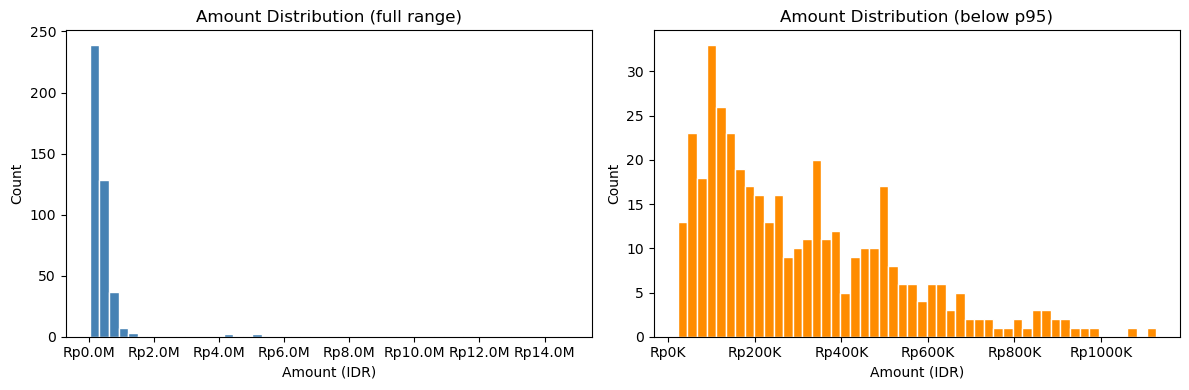

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
txn['amount'].plot(kind='hist', bins=50, ax=axes[0],
                   color='steelblue', edgecolor='white',
                   title='Amount Distribution (full range)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'Rp{x/1e6:.1f}M'))

txn[txn['amount'] <= txn['amount'].quantile(0.95)]['amount'].plot(
    kind='hist', bins=50, ax=axes[1],
    color='darkorange', edgecolor='white',
    title='Amount Distribution (below p95)')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'Rp{x/1e3:.0f}K'))

for ax in axes:
    ax.set_xlabel('Amount (IDR)')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../images/01_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Referential Integrity Check

In [10]:
orphan_users     = txn[~txn['user_id'].isin(users['user_id'])]
orphan_devices   = txn[~txn['device_id'].isin(devices['device_id'])]
orphan_merchants = txn[~txn['merchant_id'].isin(merchants['merchant_id'])]

print(f'Orphan user_id     : {len(orphan_users)}')
print(f'Orphan device_id   : {len(orphan_devices)}')
print(f'Orphan merchant_id : {len(orphan_merchants)}')

Orphan user_id     : 0
Orphan device_id   : 0
Orphan merchant_id : 0


## 8. Data Cleaning — Apply Transformations

In [11]:
txn_clean = txn.copy()

# Ensure binary flags are integers
txn_clean['refund_flag']     = txn_clean['refund_flag'].astype(int)
txn_clean['chargeback_flag'] = txn_clean['chargeback_flag'].astype(int)

# Sort by user and time for downstream window calculations
txn_clean = txn_clean.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

# Derived: transaction date and hour
txn_clean['txn_date'] = txn_clean['timestamp'].dt.date
txn_clean['txn_hour'] = txn_clean['timestamp'].dt.hour
txn_clean['txn_dow']  = txn_clean['timestamp'].dt.dayofweek  # 0=Mon

print('Cleaning complete.')
print(f'Shape after cleaning: {txn_clean.shape}')

Cleaning complete.
Shape after cleaning: (433, 15)


## 9. Data Quality Summary

In [12]:
checks = {
    'Total transactions'   : len(txn_clean),
    'Date range start'     : str(txn_clean['timestamp'].min()),
    'Date range end'       : str(txn_clean['timestamp'].max()),
    'Null values'          : txn_clean.isnull().sum().sum(),
    'Duplicate IDs'        : txn_clean.duplicated('transaction_id').sum(),
    'Non-positive amounts' : (txn_clean['amount'] <= 0).sum(),
    'Orphan user_id'       : (~txn_clean['user_id'].isin(users['user_id'])).sum(),
    'Refunded transactions': txn_clean['refund_flag'].sum(),
    'Chargebacks'          : txn_clean['chargeback_flag'].sum(),
}

summary_df = pd.DataFrame.from_dict(checks, orient='index', columns=['Value'])
print('\n=== DATA QUALITY SUMMARY ===')
print(summary_df.to_string())


=== DATA QUALITY SUMMARY ===
                                     Value
Total transactions                     433
Date range start       2024-01-01 04:18:40
Date range end         2024-06-29 21:25:56
Null values                              0
Duplicate IDs                            0
Non-positive amounts                     0
Orphan user_id                           0
Refunded transactions                   40
Chargebacks                              9


txn_clean.to_csv(DATA_DIR / 'transactions_clean.csv', index=False)
print('transactions_clean.csv written ✓')
print(f'  Rows: {len(txn_clean):,}  |  Cols: {txn_clean.shape[1]}')

# Download output
from google.colab import files
files.download('/content/transactions_clean.csv')
print('Download started — save ke komputer kamu, lalu upload di notebook 02 & 03')

In [13]:
txn_clean.to_csv(DATA_DIR / 'transactions_clean.csv', index=False)
print('transactions_clean.csv written ✓')
print(f'  Rows: {len(txn_clean):,}  |  Cols: {txn_clean.shape[1]}')

transactions_clean.csv written ✓
  Rows: 433  |  Cols: 15
